# Módulo 01 — Notebook Extra: Padrões de Projeto em Machine Learning

## Objetivos desta aula

Ao final deste notebook, você será capaz de:
- Entender **o que são padrões de projeto** e por que são relevantes para ML
- Implementar o padrão **Pipeline** para encadear etapas de processamento
- Usar o padrão **Strategy** para trocar algoritmos sem mudar o código principal
- Aplicar o padrão **Factory** para instanciar modelos de forma flexível
- Monitorar treinamentos com o padrão **Observer**

---

## O que são Padrões de Projeto?

**Padrões de projeto** (*design patterns*) são soluções reutilizáveis para problemas recorrentes em engenharia de software. Foram sistematizados no livro clássico do *Gang of Four* (GoF) em 1994.

Em Machine Learning, os mesmos problemas aparecem sempre:
- Como encadear pré-processamento → features → modelo de forma limpa?
- Como testar vários algoritmos sem duplicar código?
- Como registrar métricas durante o treinamento?

Os padrões que veremos hoje resolvem exatamente isso.

---

## Padrão 1: Pipeline

**Problema:** Em ML temos várias etapas sequenciais (normalizar → extrair features → classificar). Se cada etapa depende da anterior, o código fica emaranhado.

**Solução:** Um Pipeline encadeia etapas, onde a saída de uma é a entrada da próxima. Cada etapa tem uma interface comum (`fit`, `transform`, `predict`).

```
Dado bruto → [Etapa 1: Normalizar] → [Etapa 2: PCA] → [Etapa 3: Classificar] → Predição
```


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from abc import ABC, abstractmethod
from typing import Any, List, Optional
import time

np.random.seed(42)

print('Bibliotecas carregadas.')

Bibliotecas carregadas.


##### PADRÃO PIPELINE — Implementação from scratch

In [2]:
class Transformador(ABC):
    """Interface comum para toda etapa do pipeline."""

    @abstractmethod
    def fit(self, X: np.ndarray, y: Optional[np.ndarray] = None) -> 'Transformador':
        """Aprende parâmetros a partir dos dados de treino."""
        ...

    @abstractmethod
    def transform(self, X: np.ndarray) -> np.ndarray:
        """Aplica a transformação nos dados."""
        ...

    def fit_transform(self, X: np.ndarray, y: Optional[np.ndarray] = None) -> np.ndarray:
        """Atalho: fit seguido de transform."""
        return self.fit(X, y).transform(X)


class NormalizadorZScore(Transformador):
    """Normalização Z-score: (x - média) / desvio_padrão"""

    def fit(self, X, y=None):
        self.media_ = X.mean(axis=0)
        self.std_   = X.std(axis=0) + 1e-8  # +ε para evitar erro de divisão por zero
        return self

    def transform(self, X):
        return (X - self.media_) / self.std_


class RemovedorOutliers(Transformador):
    """Remove linhas onde alguma feature está além de k desvios padrão."""

    def __init__(self, k: float = 3.0):
        self.k = k

    def fit(self, X, y=None):
        self.media_ = X.mean(axis=0)
        self.std_   = X.std(axis=0) + 1e-8
        return self

    def transform(self, X):
        z = np.abs((X - self.media_) / self.std_)
        mascara = (z < self.k).all(axis=1)
        return X[mascara]

print('Classes de transformação definidas.')

Classes de transformação definidas.


##### A classe Pipeline em si

In [3]:
class Pipeline:
    """
    Encadeia múltiplos transformadores.
    Todas as etapas intermediárias precisam ter fit e transform.
    A última etapa pode ser um classificador (com predict).
    """

    def __init__(self, etapas: List[tuple]):
        # etapas = [("nome", objeto_transformador), ...]
        self.etapas = etapas

    def fit(self, X, y=None):
        X_atual = X
        for nome, etapa in self.etapas[:-1]:  # todas exceto a última
            print(f'  Treinando etapa: {nome}')
            X_atual = etapa.fit_transform(X_atual, y)

        # Última etapa: pode ser um classificador
        nome_final, etapa_final = self.etapas[-1]
        print(f'  Treinando etapa final: {nome_final}')
        if hasattr(etapa_final, 'fit'):
            etapa_final.fit(X_atual, y)

        return self

    def transform(self, X):
        X_atual = X
        for nome, etapa in self.etapas:
            X_atual = etapa.transform(X_atual)
        return X_atual

    def fit_transform(self, X, y=None):
        X_atual = X
        for nome, etapa in self.etapas:
            X_atual = etapa.fit_transform(X_atual, y)
        return X_atual

    def predict(self, X):
        # Aplica todas as transformações, depois predict na última etapa
        X_atual = X
        for nome, etapa in self.etapas[:-1]:
            X_atual = etapa.transform(X_atual)
        _, etapa_final = self.etapas[-1]
        return etapa_final.predict(X_atual)

print('Classe Pipeline definida.')

Classe Pipeline definida.


##### Demonstração: Pipeline de pré-processamento de features de voz

In [4]:
# Dados simulados: features brutas de áudio (pitch, energia, zcr)
np.random.seed(42)
X_treino = np.random.randn(200, 3) * np.array([50, 0.05, 0.02]) + np.array([160, 0.07, 0.05])

In [6]:
# Adicionando alguns outliers
X_treino[0] = [500, 1.0, 0.5]  # outlier extremo
X_treino[1] = [-100, -0.5, -0.3]

print(f'Dados originais: {X_treino.shape}')
print(f'Média das features: {X_treino.mean(axis=0).round(2)}')
print(f'Desvio-padrão das features: {X_treino.std(axis=0).round(2)}')

Dados originais: (200, 3)
Média das features: [1.6302e+02 6.0000e-02 5.0000e-02]
Desvio-padrão das features: [5.357e+01 9.000e-02 5.000e-02]


In [ ]:
# Montando o pipeline
pipeline_preproc = Pipeline([
    ('remover_outliers', RemovedorOutliers(k=3.0)),
    ('normalizar',       NormalizadorZScore()),
])

print('\nAplicando pipeline:')
X_processado = pipeline_preproc.fit_transform(X_treino)

print(f'\nDados processados: {X_processado.shape}')
print(f'Média após normalização: {X_processado.mean(axis=0).round(2)}')  # ≈ 0
print(f'Desvio-padrão após normalização:   {X_processado.std(axis=0).round(2)}')   # ≈ 1


Aplicando pipeline:

Dados processados: (198, 3)
Média após normalização: [-0.  0.  0.]
Desvio-padrão após normalização:   [1. 1. 1.]


---

## Padrão 2: Strategy

**Problema:** Você quer testar vários algoritmos de classificação (KNN, SVM, Árvore de Decisão) no mesmo dataset. Como fazer isso sem duplicar todo o código de avaliação?

**Solução:** O padrão Strategy define uma **família de algoritmos**, encapsula cada um, e torna-os intercambiáveis. O código que usa o algoritmo não sabe qual deles está sendo usado — só que ele tem uma interface comum.

```
Contexto (avaliador) → usa → [Estratégia: KNN]
                           → ou → [Estratégia: SVM]
                           → ou → [Estratégia: Árvore]
```


##### PADRÃO STRATEGY — Algoritmos intercambiáveis

In [ ]:
class EstrategiaClassificacao(ABC):
    """Interface comum para qualquer algoritmo de classificação."""

    @abstractmethod
    def treinar(self, X_treino, y_treino) -> None:
        ...

    @abstractmethod
    def prever(self, X_teste) -> np.ndarray:
        ...

    @property
    @abstractmethod
    def nome(self) -> str:
        ...


# --- Estratégia 1: KNN from scratch ---
class KNNStrategy(EstrategiaClassificacao):

    def __init__(self, k: int = 5):
        self.k = k

    @property
    def nome(self):
        return f'KNN (k={self.k})'

    def treinar(self, X_treino, y_treino):
        # KNN não treina, só memoriza!
        self.X_treino = X_treino
        self.y_treino = y_treino

    def prever(self, X_teste):
        predicoes = []
        for x in X_teste:
            # Distância euclidiana para todos os pontos de treino
            distancias = np.sqrt(np.sum((self.X_treino - x) ** 2, axis=1))
            # Índices dos K vizinhos mais próximos
            vizinhos = np.argsort(distancias)[:self.k]
            # Voto majoritário
            labels_viz = self.y_treino[vizinhos]
            classe, _ = np.unique(labels_viz, return_counts=True)
            predicoes.append(classe[np.argmax(_)])
        return np.array(predicoes)


# --- Estratégia 2: Classificador Bayesiano Ingênuo (Gaussiano) ---
class NaiveBayesStrategy(EstrategiaClassificacao):

    @property
    def nome(self):
        return 'Naive Bayes Gaussiano'

    def treinar(self, X_treino, y_treino):
        self.classes_ = np.unique(y_treino)
        self.medias_  = {}
        self.vars_    = {}
        self.priors_  = {}
        n = len(y_treino)
        for c in self.classes_:
            X_c = X_treino[y_treino == c]
            self.medias_[c]  = X_c.mean(axis=0)
            self.vars_[c]    = X_c.var(axis=0) + 1e-9
            self.priors_[c]  = len(X_c) / n

    def _log_likelihood(self, x, c):
        """Log P(x | classe=c) assumindo Gaussiana por feature."""
        mu, var = self.medias_[c], self.vars_[c]
        return -0.5 * np.sum(np.log(2 * np.pi * var) + (x - mu) ** 2 / var)

    def prever(self, X_teste):
        predicoes = []
        for x in X_teste:
            scores = {
                c: np.log(self.priors_[c]) + self._log_likelihood(x, c)
                for c in self.classes_
            }
            predicoes.append(max(scores, key=scores.get))
        return np.array(predicoes)


# --- Contexto: Avaliador de Modelos ---
class AvaliadorModelos:
    """Avalia qualquer EstrategiaClassificacao de forma uniforme."""

    def __init__(self, estrategia: EstrategiaClassificacao):
        self.estrategia = estrategia

    def trocar_estrategia(self, nova_estrategia: EstrategiaClassificacao):
        """Troca o algoritmo em tempo de execução!"""
        self.estrategia = nova_estrategia

    def avaliar(self, X_treino, y_treino, X_teste, y_teste):
        inicio = time.time()
        self.estrategia.treinar(X_treino, y_treino)
        tempo_treino = time.time() - inicio

        inicio = time.time()
        y_pred = self.estrategia.prever(X_teste)
        tempo_pred = time.time() - inicio

        acuracia = np.mean(y_pred == y_teste)

        return {
            'modelo': self.estrategia.nome,
            'acuracia': acuracia,
            'tempo_treino_s': round(tempo_treino, 4),
            'tempo_pred_s': round(tempo_pred, 4),
        }

print('Padrão Strategy implementado.')

Padrão Strategy implementado.


##### Demonstração: comparando algoritmos no mesmo dataset

In [14]:
# Dataset sintético de 3 classes (emoções: neutro, alegria, tristeza)
rng = np.random.default_rng(42)

def gerar_dataset_emocoes(n_por_classe=100):
    centros = {'neutro': [0, 0], 'alegria': [3, 3], 'tristeza': [-3, 2]}
    X, y = [], []
    for i, (emocao, centro) in enumerate(centros.items()):
        X.append(rng.normal(centro, 1.0, (n_por_classe, 2)))
        y.extend([i] * n_por_classe)
    return np.vstack(X), np.array(y)

X, y = gerar_dataset_emocoes(500)

In [15]:
# Split manual 80/20
n_treino = int(0.8 * len(X))
idx = rng.permutation(len(X))
X_treino, y_treino = X[idx[:n_treino]], y[idx[:n_treino]]
X_teste, y_teste   = X[idx[n_treino:]], y[idx[n_treino:]]

# Normalizar antes
norm = NormalizadorZScore()
X_treino_n = norm.fit_transform(X_treino)
X_teste_n  = norm.transform(X_teste)

# Avaliando estratégias
avaliador = AvaliadorModelos(KNNStrategy(k=5))
resultados = []

for estrategia in [KNNStrategy(k=3), KNNStrategy(k=5), KNNStrategy(k=7), NaiveBayesStrategy()]:
    avaliador.trocar_estrategia(estrategia)
    res = avaliador.avaliar(X_treino_n, y_treino, X_teste_n, y_teste)
    resultados.append(res)
    print(f"[{res['modelo']:30s}]  Acurácia: {res['acuracia']:.3f}  "
          f"Treino: {res['tempo_treino_s']:.4f}s  Predição: {res['tempo_pred_s']:.4f}s")

print('\nObserve como trocamos o algoritmo SEM mudar o código do avaliador!')

[KNN (k=3)                     ]  Acurácia: 0.967  Treino: 0.0000s  Predição: 0.0652s
[KNN (k=5)                     ]  Acurácia: 0.973  Treino: 0.0000s  Predição: 0.0500s
[KNN (k=7)                     ]  Acurácia: 0.973  Treino: 0.0000s  Predição: 0.0576s
[Naive Bayes Gaussiano         ]  Acurácia: 0.963  Treino: 0.0015s  Predição: 0.0145s

Observe como trocamos o algoritmo SEM mudar o código do avaliador!


---

## Padrão 3: Factory

**Problema:** Você quer instanciar modelos a partir de strings de configuração (ex: arquivo YAML) sem um `if/elif` gigante espalhado pelo código.

**Solução:** Uma **Factory** centraliza a criação de objetos. O código cliente pede um objeto pelo nome, e a factory decide como criar.

```python
modelo = ModelFactory.criar('knn', k=5)    # retorna KNNStrategy(k=5)
modelo = ModelFactory.criar('bayes')        # retorna NaiveBayesStrategy()
```


##### PADRÃO FACTORY — Criação centralizada de objetos

In [16]:
class ModeloFactory:
    """Factory para criar estratégias de classificação."""

    # Registro de modelos disponíveis
    _registro = {
        'knn':         KNNStrategy,
        'naive_bayes': NaiveBayesStrategy,
        # Adicione novos modelos aqui sem mudar o resto do código!
    }

    @classmethod
    def criar(cls, nome: str, **kwargs) -> EstrategiaClassificacao:
        if nome not in cls._registro:
            modelos_disponiveis = list(cls._registro.keys())
            raise ValueError(f"Modelo '{nome}' desconhecido. "
                             f"Disponíveis: {modelos_disponiveis}")
        return cls._registro[nome](**kwargs)

    @classmethod
    def registrar(cls, nome: str, classe):
        """Registra um novo tipo de modelo dinamicamente."""
        cls._registro[nome] = classe
        print(f"Modelo '{nome}' registrado com sucesso.")

    @classmethod
    def listar_modelos(cls):
        return list(cls._registro.keys())

In [19]:
# Demonstração
print('Modelos disponíveis:', ModeloFactory.listar_modelos())

# Criando modelos a partir de strings
config_experimento = [
    {'nome': 'knn', 'k': 3},
    {'nome': 'knn', 'k': 9},
    {'nome': 'naive_bayes'},
]

print('\nCriando modelos a partir de configuração:')
for config in config_experimento:
    nome = config.pop('nome')
    modelo = ModeloFactory.criar(nome, **config)
    print(f'  → Criado: {modelo.nome}')

Modelos disponíveis: ['knn', 'naive_bayes']

Criando modelos a partir de configuração:
  → Criado: KNN (k=3)
  → Criado: KNN (k=9)
  → Criado: Naive Bayes Gaussiano


##### Extensibilidade: registrando um novo modelo

In [20]:
class RegressaoLogisticaSimples(EstrategiaClassificacao):
    """Regressão Logística Binária from scratch (gradiente descendente)."""

    def __init__(self, lr: float = 0.01, epocas: int = 100):
        self.lr = lr
        self.epocas = epocas

    @property
    def nome(self):
        return f'Regressão Logística (lr={self.lr}, épocas={self.epocas})'

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def treinar(self, X, y):
        # Para simplificar, treina apenas para classificação binária (y ∈ {0, 1})
        # Adicionamos bias como coluna extra
        X_b = np.hstack([np.ones((len(X), 1)), X])
        self.w = np.zeros(X_b.shape[1])

        for _ in range(self.epocas):
            y_hat = self._sigmoid(X_b @ self.w)
            erro  = y_hat - y
            grad  = X_b.T @ erro / len(y)
            self.w -= self.lr * grad

    def prever(self, X):
        X_b = np.hstack([np.ones((len(X), 1)), X])
        probs = self._sigmoid(X_b @ self.w)
        return (probs >= 0.5).astype(int)

In [21]:
# Registrando na factory
ModeloFactory.registrar('logistica', RegressaoLogisticaSimples)
print('Modelos disponíveis agora:', ModeloFactory.listar_modelos())

# Usando o novo modelo
modelo_log = ModeloFactory.criar('logistica', lr=0.1, epocas=200)
print(f'Criado: {modelo_log.nome}')

Modelo 'logistica' registrado com sucesso.
Modelos disponíveis agora: ['knn', 'naive_bayes', 'logistica']
Criado: Regressão Logística (lr=0.1, épocas=200)


---

## Padrão 4: Observer

**Problema:** Durante o treinamento de um modelo, você quer registrar métricas, salvar checkpoints, e plotar gráficos — mas não quer misturar essa lógica com o algoritmo de aprendizado.

**Solução:** O padrão **Observer** (também chamado de Publish-Subscribe) define um mecanismo de **notificação de eventos**. O objeto que treina (sujeito) notifica observadores registrados quando algo acontece.

```
Treinamento (Sujeito) → notifica → [Logger]
                                 → notifica → [Plotador]
                                 → notifica → [EarlyStopping]
```


##### PADRÃO OBSERVER — Monitoramento de treinamento

In [29]:
class ObservadorTreino(ABC):
    """Interface para qualquer observador de eventos de treinamento."""

    @abstractmethod
    def ao_iniciar(self, config: dict) -> None:
        ...

    @abstractmethod
    def ao_terminar_epoca(self, epoca: int, metricas: dict) -> None:
        ...

    @abstractmethod
    def ao_finalizar(self, historico: list) -> None:
        ...


# --- Observador 1: Logger de texto ---
class LoggerConsole(ObservadorTreino):

    def ao_iniciar(self, config):
        print(f"[Logger] Treinamento iniciado. Config: {config}")

    def ao_terminar_epoca(self, epoca, metricas):
        if epoca % 20 == 0:
            linha = f"[Logger] Época {epoca:4d}"
            for k, v in metricas.items():
                linha += f" | {k}: {v:.4f}"
            print(linha)

    def ao_finalizar(self, historico):
        print(f"[Logger] Treinamento concluído. {len(historico)} épocas.")


# --- Observador 2: Early Stopping ---
class EarlyStopping(ObservadorTreino):

    def __init__(self, paciencia: int = 10, metrica: str = 'loss'):
        self.paciencia = paciencia
        self.metrica = metrica
        self.melhor_valor = float('inf')
        self.contagem = 0
        self.parar = False  # flag lida pelo loop de treinamento

    def ao_iniciar(self, config):
        self.melhor_valor = float('inf')
        self.contagem = 0
        self.parar = False
        print(f"[EarlyStopping] Monitorando '{self.metrica}' (paciência={self.paciencia})")

    def ao_terminar_epoca(self, epoca, metricas):
        valor_atual = metricas.get(self.metrica, float('inf'))
        if valor_atual < self.melhor_valor:
            self.melhor_valor = valor_atual
            self.contagem = 0
        else:
            self.contagem += 1
            if self.contagem >= self.paciencia:
                print(f"[EarlyStopping] Parado na época {epoca}. "
                      f"Melhor {self.metrica}: {self.melhor_valor:.4f}")
                self.parar = True

    def ao_finalizar(self, historico):
        pass


# --- Observador 3: Coletor de histórico ---
class HistoricoTreino(ObservadorTreino):

    def __init__(self):
        self.epocas = []
        self.historico = []

    def ao_iniciar(self, config):
        self.epocas.clear()
        self.historico.clear()

    def ao_terminar_epoca(self, epoca, metricas):
        self.epocas.append(epoca)
        self.historico.append(metricas)

    def ao_finalizar(self, historico):
        pass

    def plotar(self, metrica: str = 'loss'):
        valores = [m[metrica] for m in self.historico if metrica in m]
        plt.figure(figsize=(10, 4))
        plt.plot(self.epocas[:len(valores)], valores, linewidth=2)
        plt.xlabel('Época')
        plt.ylabel(metrica)
        plt.title(f'Evolução de {metrica} durante o treinamento')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

print('Observadores definidos.')

Observadores definidos.


##### Classe de treinamento que usa Observer

In [24]:
class TreinadorGradiente:
    """Simula um loop de treinamento por gradiente descendente."""

    def __init__(self):
        self._observadores: List[ObservadorTreino] = []

    def registrar_observador(self, obs: ObservadorTreino):
        self._observadores.append(obs)

    def _notificar_inicio(self, config):
        for obs in self._observadores:
            obs.ao_iniciar(config)

    def _notificar_epoca(self, epoca, metricas):
        for obs in self._observadores:
            obs.ao_terminar_epoca(epoca, metricas)

    def _notificar_fim(self, historico):
        for obs in self._observadores:
            obs.ao_finalizar(historico)

    def treinar(self, X, y, epocas=100, lr=0.01):
        config = {'epocas': epocas, 'lr': lr, 'n_amostras': len(X)}
        self._notificar_inicio(config)

        historico = []
        # Parâmetros simples (regressão linear como simulação)
        w = np.zeros(X.shape[1])
        b = 0.0

        early = next((o for o in self._observadores
                      if isinstance(o, EarlyStopping)), None)

        for ep in range(1, epocas + 1):
            # Forward pass
            y_hat = X @ w + b
            loss = np.mean((y - y_hat) ** 2)

            # Backward pass
            residuo = y_hat - y
            dw = 2 * X.T @ residuo / len(y)
            db = 2 * residuo.mean()
            w -= lr * dw
            b -= lr * db

            # Acurácia simulada (para fins de demonstração)
            acc = 1.0 - loss / (np.var(y) + 1e-8)
            metricas = {'loss': float(loss), 'acc': max(0, float(acc))}
            historico.append(metricas)
            self._notificar_epoca(ep, metricas)

            if early and early.parar:
                break

        self._notificar_fim(historico)
        return historico

--- Iniciando treinamento ---
[Logger] Treinamento iniciado. Config: {'epocas': 200, 'lr': 0.05, 'n_amostras': 100}
[EarlyStopping] Monitorando 'loss' (paciência=15)
[Logger] Época   20 | loss: 0.1779 | acc: 0.9672
[Logger] Época   40 | loss: 0.0834 | acc: 0.9846
[Logger] Época   60 | loss: 0.0809 | acc: 0.9851
[Logger] Época   80 | loss: 0.0808 | acc: 0.9851
[Logger] Época  100 | loss: 0.0808 | acc: 0.9851
[Logger] Época  120 | loss: 0.0808 | acc: 0.9851
[Logger] Época  140 | loss: 0.0808 | acc: 0.9851
[Logger] Época  160 | loss: 0.0808 | acc: 0.9851
[Logger] Época  180 | loss: 0.0808 | acc: 0.9851
[Logger] Época  200 | loss: 0.0808 | acc: 0.9851
[Logger] Treinamento concluído. 200 épocas.


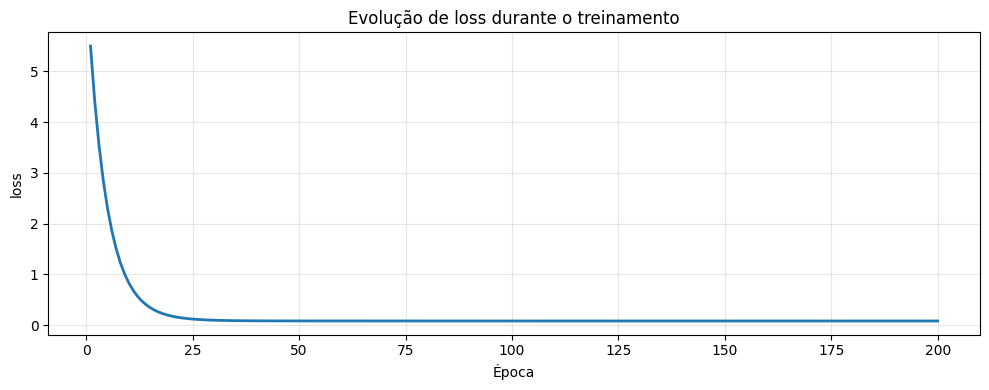

In [28]:
# Dataset simples
X_demo = np.random.randn(100, 3)
y_demo = X_demo @ np.array([2, -1, 0.5]) + np.random.randn(100) * 0.3

# Instanciando observadores
logger    = LoggerConsole()
stopper   = EarlyStopping(paciencia=15, metrica='loss')
historico = HistoricoTreino()

# Configurando o treinador
treinador = TreinadorGradiente()
treinador.registrar_observador(logger)
treinador.registrar_observador(stopper)
treinador.registrar_observador(historico)

# Treinando
print('--- Iniciando treinamento ---')
hist = treinador.treinar(X_demo, y_demo, epocas=200, lr=0.05)

# Plotando histórico
historico.plotar('loss')

---

## Padrão 5: Template Method

**Problema:** Vários algoritmos compartilham a mesma sequência de passos (ex: todos os algoritmos de ML têm: validar dados → treinar → avaliar), mas os detalhes de cada passo variam.

**Solução:** O **Template Method** define o esqueleto do algoritmo na classe base, deixando que subclasses preencham os detalhes específicos.


##### PADRÃO TEMPLATE METHOD

In [30]:
class ExperimentoML(ABC):
    """
    Template para experimentos de ML.
    Define o esqueleto: carregar → preprocessar → treinar → avaliar → reportar.
    Subclasses implementam os hooks específicos.
    """

    def executar(self):
        """Método template — não sobrescreva!"""
        print(f"\n{'='*50}")
        print(f"Experimento: {self.__class__.__name__}")
        print('='*50)

        X, y         = self.carregar_dados()
        X_t, X_v, y_t, y_v = self.preprocessar(X, y)
        modelo       = self.treinar(X_t, y_t)
        metricas     = self.avaliar(modelo, X_v, y_v)
        self.reportar(metricas)
        return metricas

    @abstractmethod
    def carregar_dados(self):
        ...

    def preprocessar(self, X, y):
        """Hook com implementação padrão — subclasses podem sobrescrever."""
        n = int(0.8 * len(X))
        idx = np.random.permutation(len(X))
        return X[idx[:n]], X[idx[n:]], y[idx[:n]], y[idx[n:]]

    @abstractmethod
    def treinar(self, X_treino, y_treino):
        ...

    @abstractmethod
    def avaliar(self, modelo, X_val, y_val) -> dict:
        ...

    def reportar(self, metricas: dict):
        """Hook com implementação padrão."""
        print('\nResultados:')
        for k, v in metricas.items():
            print(f'  {k}: {v}')


# Subclasse concreta
class ExperimentoKNN(ExperimentoML):

    def __init__(self, k=5):
        self.k = k

    def carregar_dados(self):
        # Simula carregamento de features de voz
        rng = np.random.default_rng(99)
        X = np.vstack([
            rng.normal([0, 0], 1, (100, 2)),
            rng.normal([4, 4], 1, (100, 2)),
            rng.normal([-4, 4], 1, (100, 2)),
        ])
        y = np.repeat([0, 1, 2], 100)
        print(f'  Dados carregados: {X.shape[0]} amostras, {X.shape[1]} features')
        return X, y

    def preprocessar(self, X, y):
        norm = NormalizadorZScore()
        X_n = norm.fit_transform(X)
        return super().preprocessar(X_n, y)

    def treinar(self, X_treino, y_treino):
        modelo = KNNStrategy(k=self.k)
        modelo.treinar(X_treino, y_treino)
        print(f'  Modelo treinado: {modelo.nome}')
        return modelo

    def avaliar(self, modelo, X_val, y_val):
        y_pred = modelo.prever(X_val)
        acuracia = np.mean(y_pred == y_val)
        return {'acuracia': f'{acuracia:.3f}', 'n_val': len(y_val)}
    
# Subclasse concreta
class ExperimentoNaiveBayes(ExperimentoML):

    def __init__(self):
        pass

    def carregar_dados(self):
        # Simula carregamento de features de voz
        rng = np.random.default_rng(99)
        X = np.vstack([
            rng.normal([2, 2], 1, (100, 2)),
            rng.normal([4, 4], 1, (100, 2)),
            rng.normal([-4, 4], 1, (100, 2)),
        ])
        y = np.repeat([0, 1, 2], 100)
        print(f'  Dados carregados: {X.shape[0]} amostras, {X.shape[1]} features')
        return X, y

    def preprocessar(self, X, y):
        norm = NormalizadorZScore()
        rem_outliers = RemovedorOutliers(k=3.0)
        X_n = rem_outliers.fit_transform(X)
        X_n = norm.fit_transform(X_n)
        return super().preprocessar(X_n, y)

    def treinar(self, X_treino, y_treino):
        modelo = NaiveBayesStrategy()
        modelo.treinar(X_treino, y_treino)
        print(f'  Modelo treinado: {modelo.nome}')
        return modelo

    def avaliar(self, modelo, X_val, y_val):
        y_pred = modelo.prever(X_val)
        acuracia = np.mean(y_pred == y_val)
        return {'acuracia': f'{acuracia:.3f}', 'n_val': len(y_val)}

In [31]:
# Executando
exp = ExperimentoKNN(k=5)
metricas = exp.executar()


Experimento: ExperimentoKNN
  Dados carregados: 300 amostras, 2 features
  Modelo treinado: KNN (k=5)

Resultados:
  acuracia: 0.983
  n_val: 60


In [32]:
exp = ExperimentoNaiveBayes()
metricas = exp.executar()


Experimento: ExperimentoNaiveBayes
  Dados carregados: 300 amostras, 2 features
  Modelo treinado: Naive Bayes Gaussiano

Resultados:
  acuracia: 0.950
  n_val: 60


---

## Resumo dos Padrões

| Padrão | Problema resolvido | Quando usar |
|---|---|---|
| **Pipeline** | Encadear etapas sequenciais | Pré-processamento, transformações |
| **Strategy** | Trocar algoritmos em runtime | Comparação de modelos, A/B testing |
| **Factory** | Criar objetos a partir de configs | Experimentos configuráveis, YAML/JSON |
| **Observer** | Reagir a eventos sem acoplamento | Callbacks de treinamento, logging |
| **Template Method** | Esqueleto fixo, detalhes variáveis | Experimentos com protocolo padrão |

**Próximo notebook:** Fundamentos do scikit-learn — a biblioteca que implementa esses padrões de forma padronizada para toda a comunidade Python de ML.


---

## Resumo do Módulo 01

Completamos o Módulo 01! Aprendemos:

**NumPy e Pandas:** A base matemática e de manipulação de dados para qualquer projeto ML.

**Scikit-learn:** A biblioteca padrão que implementa esses padrões profissionalmente, com validação cruzada, busca de hiperparâmetros e avaliação robusta.

**Git:** Como organizar repositórios e organizar projetos colaborativos de ML de forma reprodutível e com registros de entregas e resultados.

**Padrões de Projeto:** Como organizar código ML de forma limpa — Pipeline (encadeamento), Strategy (algoritmos intercambiáveis), Factory (criação centralizada), Observer (callbacks de treinamento).
